In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA2'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

import tempfile, os
# Répertoire temporaire cross-platform (Windows/Linux/Mac) pour télécharger les datasets
DATA_ROOT = tempfile.gettempdir()

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)
torch.manual_seed(42)

print(f"✅ PyTorch {torch.__version__}, torchvision {torchvision.__version__}")

✅ PyTorch 2.11.0+cpu, torchvision 0.26.0+cpu


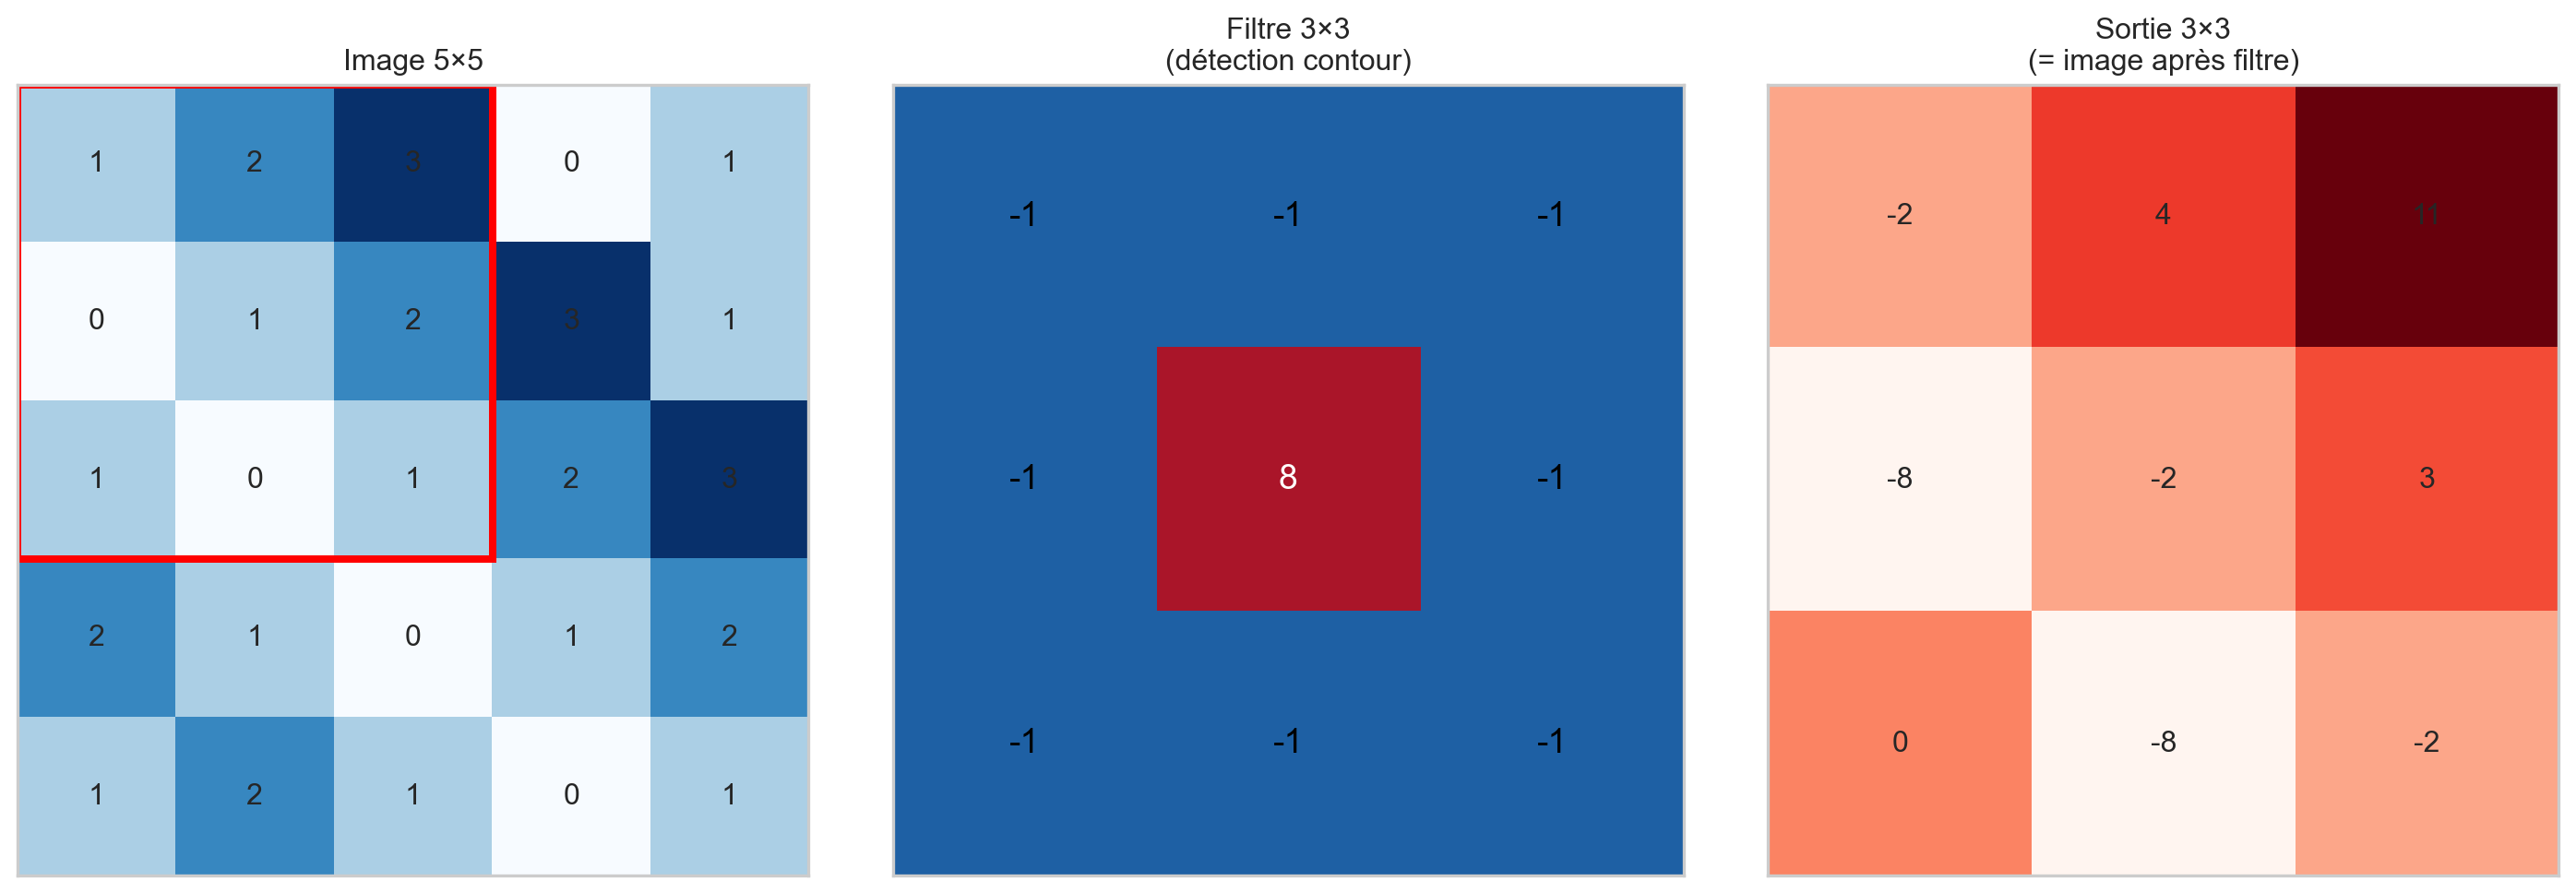

In [3]:
#| label: fig-convolution-idea
#| fig-cap: 'La convolution : un filtre qui glisse sur l''image'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Image d'entrée (exemple simple 5x5)
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 1],
    [1, 0, 1, 2, 3],
    [2, 1, 0, 1, 2],
    [1, 2, 1, 0, 1],
])

# Filtre 3x3 : détection contours
kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1],
])

# Calculer la convolution 3x3 (sortie 3x3)
sortie = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        sortie[i, j] = (image[i:i+3, j:j+3] * kernel).sum()

# Image
axes[0].imshow(image, cmap="Blues", vmin=0, vmax=3)
for (i, j), v in np.ndenumerate(image):
    axes[0].text(j, i, int(v), ha="center", va="center", fontsize=12)
axes[0].set_title("Image 5×5")
axes[0].set_xticks([]); axes[0].set_yticks([])

# Rectangle pour montrer où on applique
from matplotlib.patches import Rectangle
axes[0].add_patch(Rectangle((-0.5, -0.5), 3, 3, fill=False, edgecolor="red", linewidth=3))

# Filtre
axes[1].imshow(kernel, cmap="RdBu_r", vmin=-2, vmax=9)
for (i, j), v in np.ndenumerate(kernel):
    couleur = "white" if abs(v) > 3 else "black"
    axes[1].text(j, i, int(v), ha="center", va="center", fontsize=14, color=couleur)
axes[1].set_title("Filtre 3×3\n(détection contour)")
axes[1].set_xticks([]); axes[1].set_yticks([])

# Sortie
axes[2].imshow(sortie, cmap="Reds")
for (i, j), v in np.ndenumerate(sortie):
    axes[2].text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=12)
axes[2].set_title("Sortie 3×3\n(= image après filtre)")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.show()

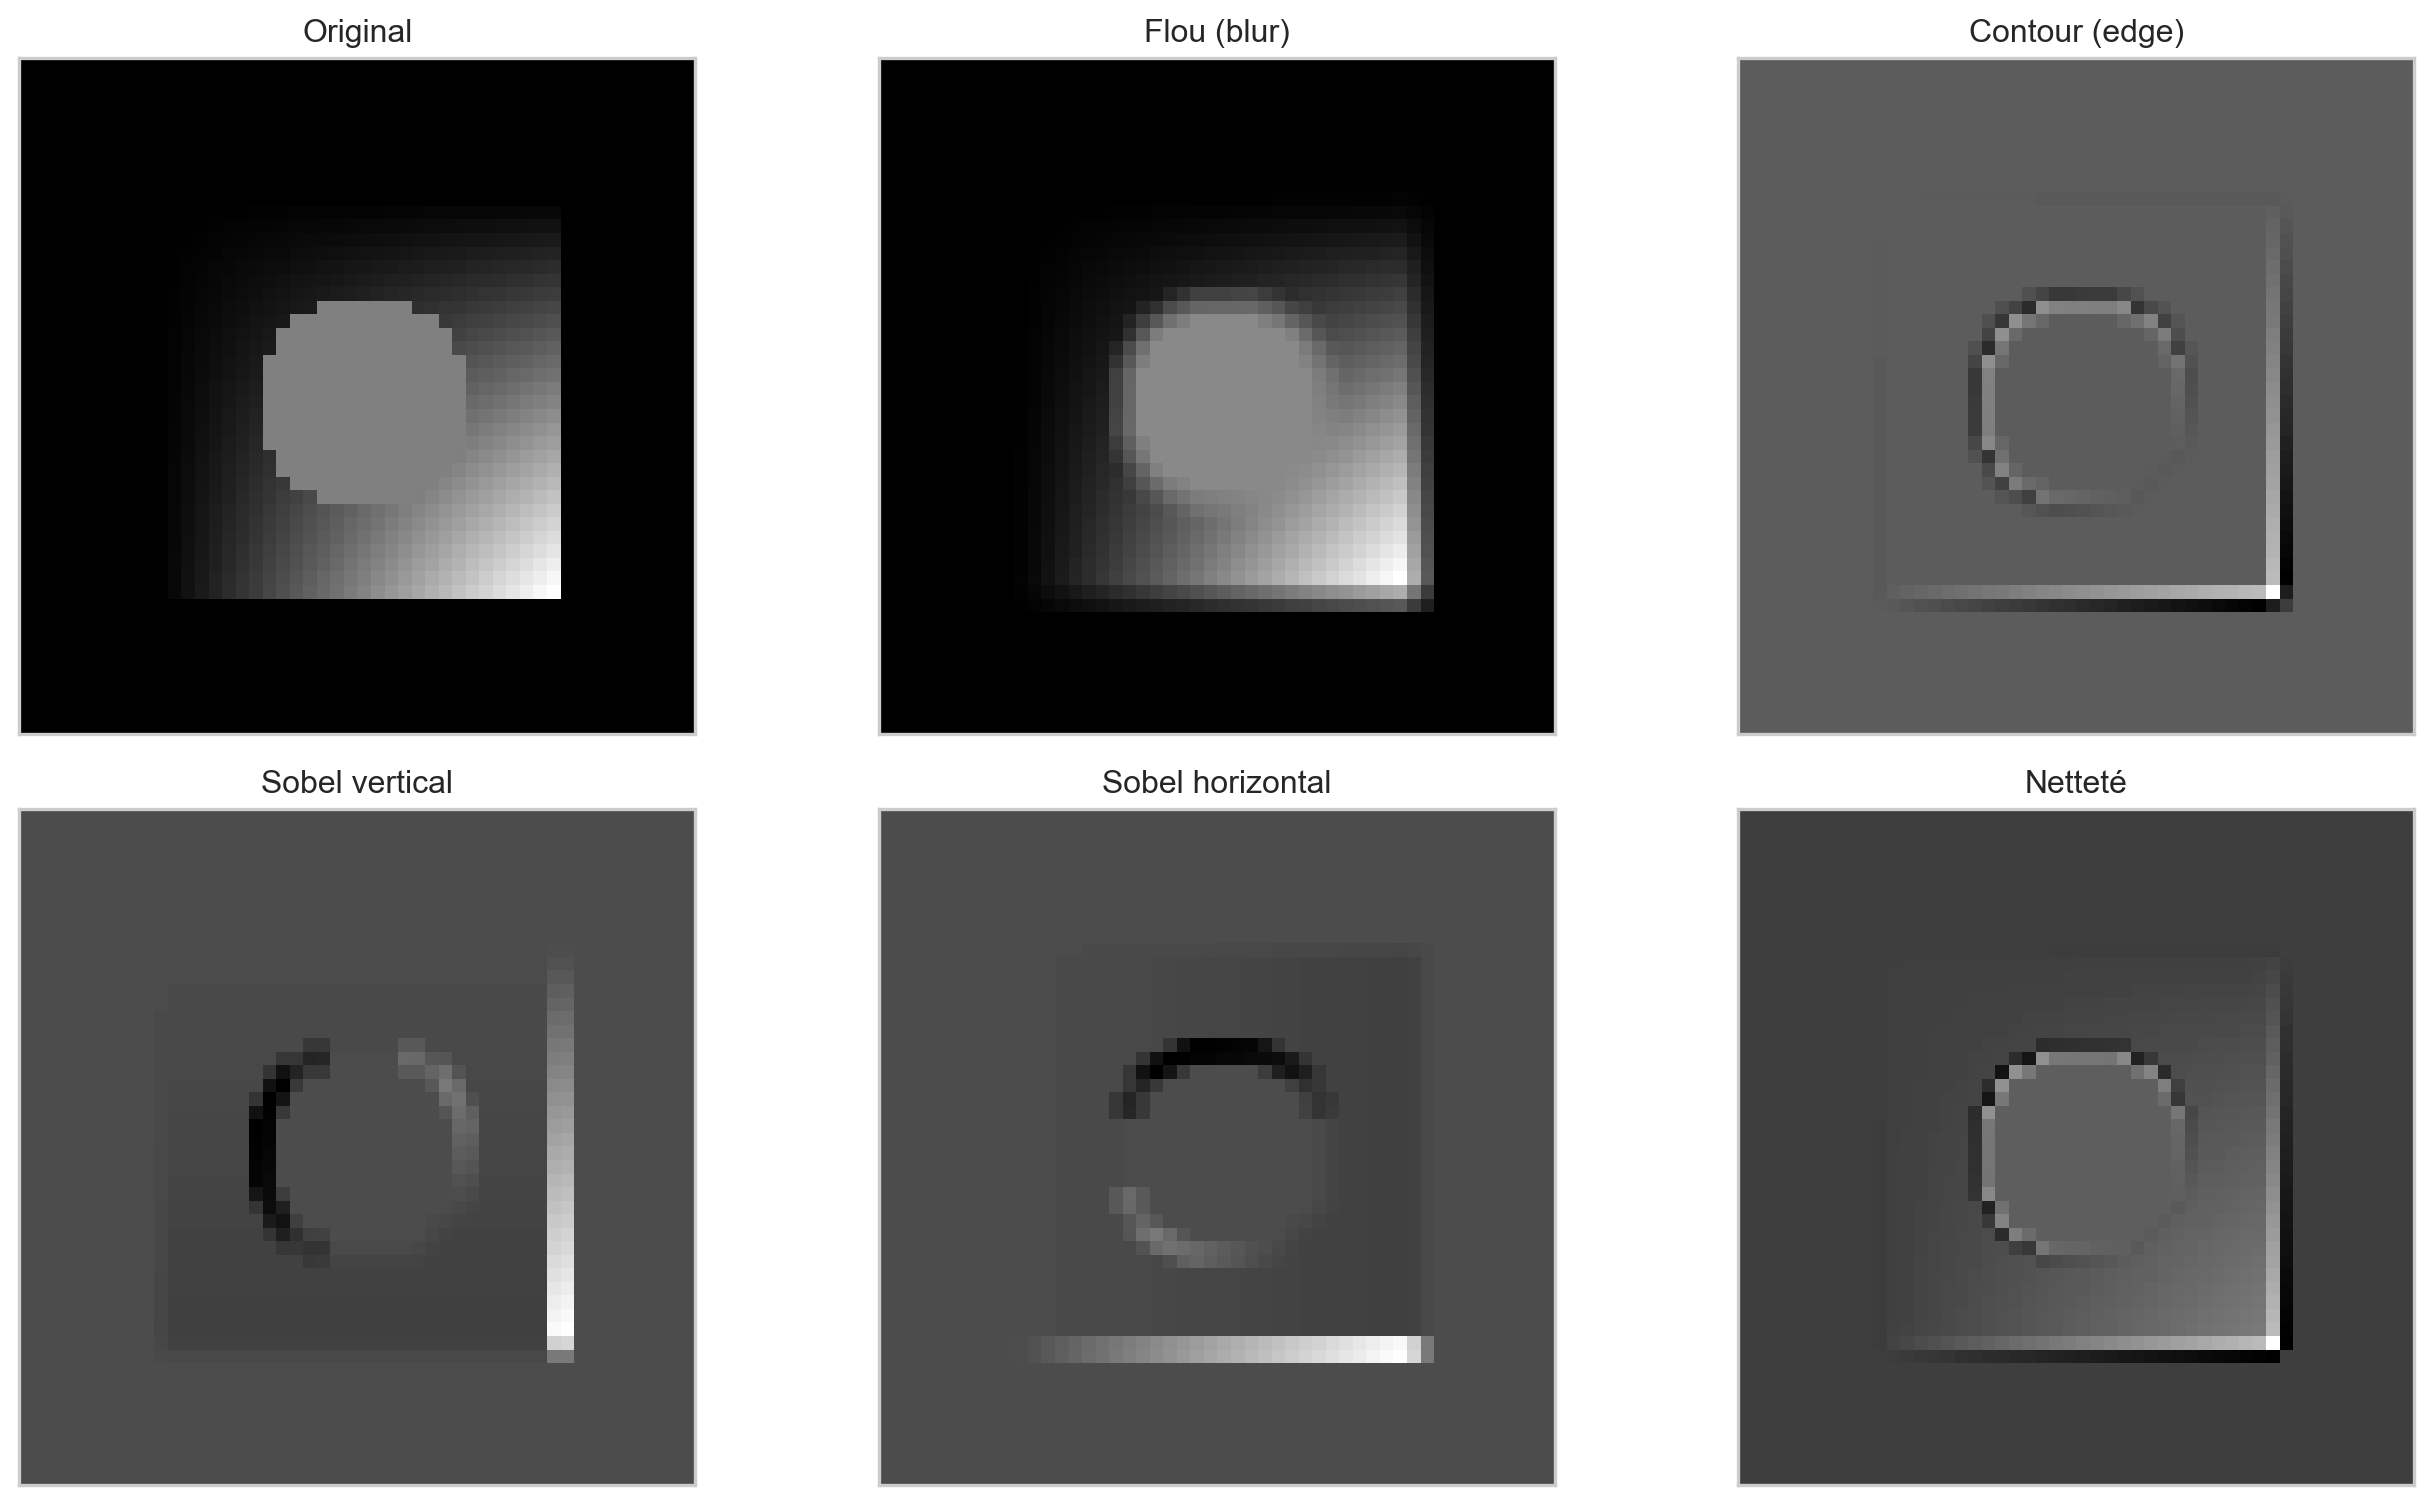

In [4]:
#| label: fig-filters-real
#| fig-cap: Différents filtres et leurs effets

from scipy.signal import convolve2d

# Créer une "image" synthétique (carré gradient + cercle)
img = np.zeros((50, 50))
img[10:40, 10:40] = np.outer(np.linspace(0, 1, 30), np.linspace(0, 1, 30))
# Cercle au centre
yy, xx = np.ogrid[:50, :50]
mask = (xx - 25)**2 + (yy - 25)**2 < 64
img[mask] = 0.5

# Différents filtres
filtres = {
    "Original": np.array([[0, 0, 0], [0, 1, 0], [0, 0, 0]]),
    "Flou (blur)": np.ones((3, 3)) / 9,
    "Contour (edge)": np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]]),
    "Sobel vertical": np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]),
    "Sobel horizontal": np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]]),
    "Netteté": np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]]),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (nom, f) in zip(axes.flat, filtres.items()):
    resultat = convolve2d(img, f, mode="same", boundary="symm")
    ax.imshow(resultat, cmap="gray")
    ax.set_title(nom, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

In [5]:
# Une couche de convolution 2D
conv = nn.Conv2d(
    in_channels=1,      # image noir et blanc
    out_channels=16,    # 16 filtres différents
    kernel_size=3,      # 3x3
    stride=1,
    padding=1,           # garder la taille
)

print(f"Nombre de paramètres du filtre : {sum(p.numel() for p in conv.parameters())}")
# = 16 filtres * (1 * 3 * 3) poids + 16 biais = 144 + 16 = 160

Nombre de paramètres du filtre : 160


In [6]:
# Image d'entrée factice (batch=1, channel=1, 28x28)
img_fake = torch.randn(1, 1, 28, 28)

# Après conv
sortie = conv(img_fake)
print(f"Shape entrée : {img_fake.shape}")
print(f"Shape sortie : {sortie.shape}")
# 1, 16, 28, 28 : toujours 28x28 (grâce au padding=1), mais 16 canaux maintenant

Shape entrée : torch.Size([1, 1, 28, 28])
Shape sortie : torch.Size([1, 16, 28, 28])


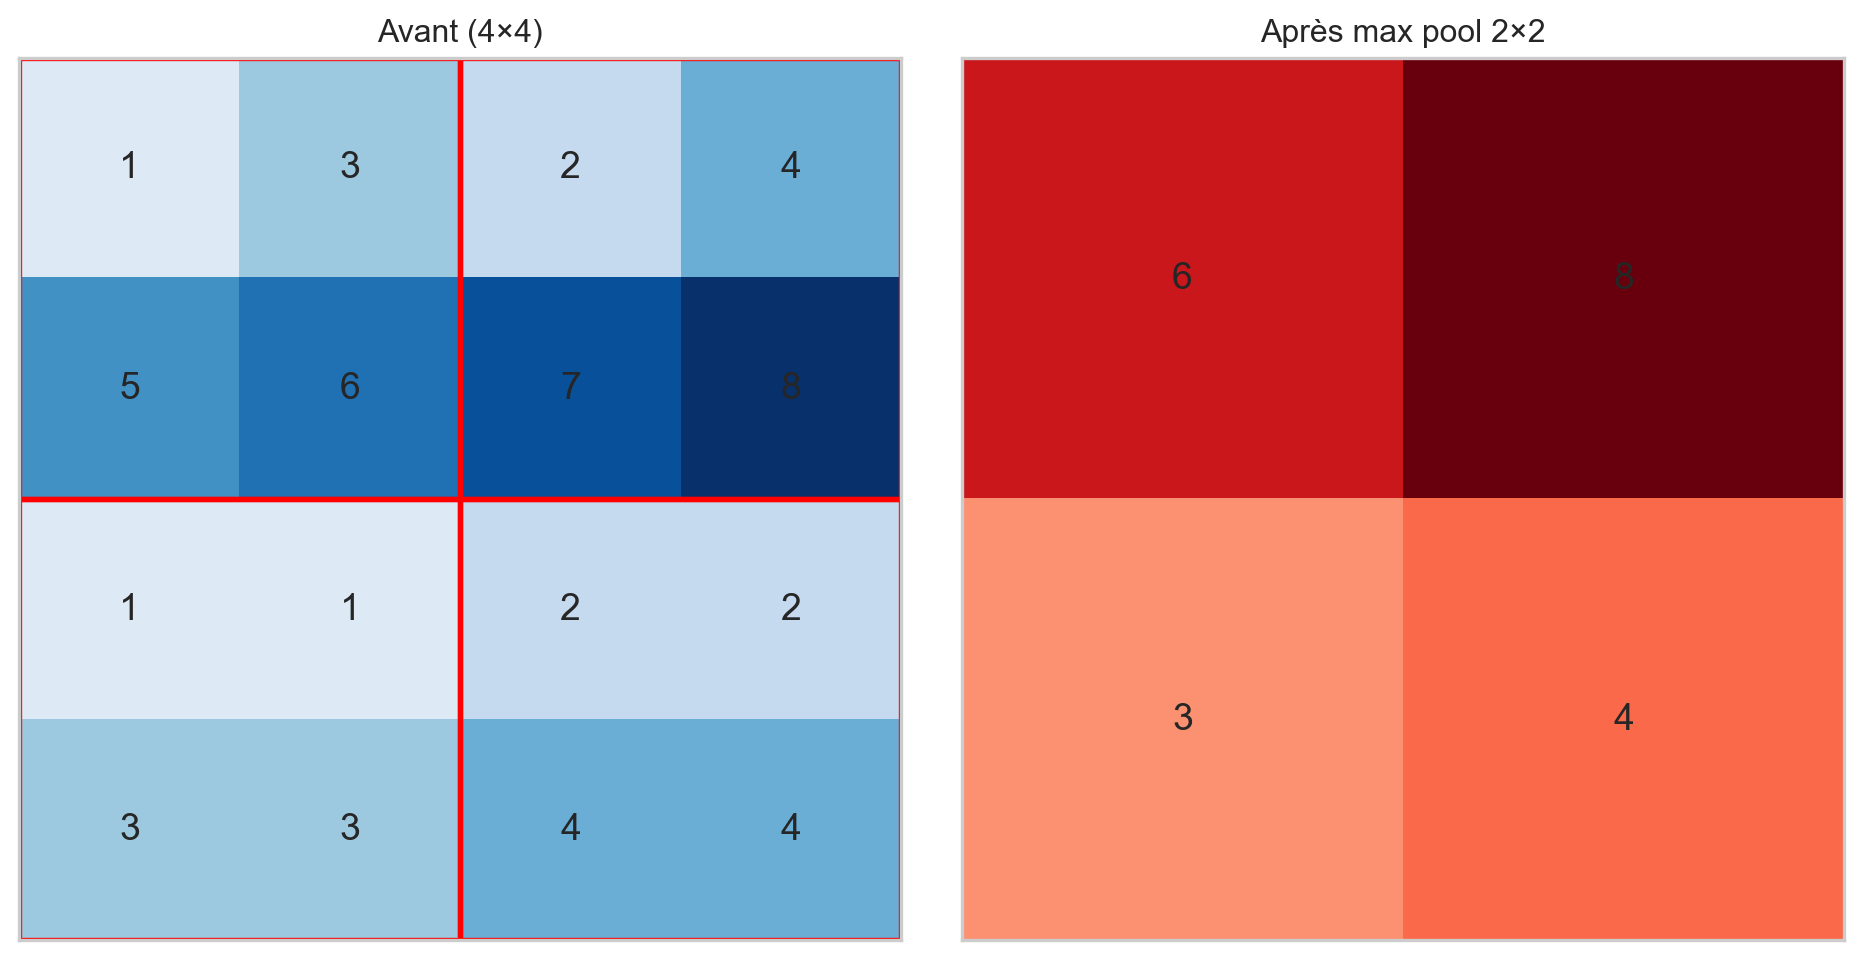

In [7]:
#| label: fig-pooling
#| fig-cap: Max pooling 2×2

img_exemple = np.array([
    [1, 3, 2, 4],
    [5, 6, 7, 8],
    [1, 1, 2, 2],
    [3, 3, 4, 4],
])

# Max pool 2x2
max_pool = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        bloc = img_exemple[i*2:i*2+2, j*2:j*2+2]
        max_pool[i, j] = bloc.max()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_exemple, cmap="Blues", vmin=0, vmax=8)
for (i, j), v in np.ndenumerate(img_exemple):
    axes[0].text(j, i, int(v), ha="center", va="center", fontsize=14)
axes[0].set_title("Avant (4×4)")
axes[0].set_xticks([]); axes[0].set_yticks([])

# Montrer les blocs 2x2
from matplotlib.patches import Rectangle
for i in range(2):
    for j in range(2):
        axes[0].add_patch(Rectangle((j*2 - 0.5, i*2 - 0.5), 2, 2, fill=False,
                                      edgecolor="red", linewidth=2))

axes[1].imshow(max_pool, cmap="Reds", vmin=0, vmax=8)
for (i, j), v in np.ndenumerate(max_pool):
    axes[1].text(j, i, int(v), ha="center", va="center", fontsize=14)
axes[1].set_title("Après max pool 2×2")
axes[1].set_xticks([]); axes[1].set_yticks([])

plt.tight_layout()
plt.show()

In [8]:
# Max pooling 2x2
pool = nn.MaxPool2d(kernel_size=2, stride=2)

# Appliqué sur notre sortie de conv précédente (1, 16, 28, 28)
apres_pool = pool(sortie)
print(f"Avant pool : {sortie.shape}")
print(f"Après pool : {apres_pool.shape}")
# 1, 16, 14, 14 : taille spatiale divisée par 2

Avant pool : torch.Size([1, 16, 28, 28])
Après pool : torch.Size([1, 16, 14, 14])


In [9]:
class LeNet(nn.Module):
    """LeNet-like pour images 28×28."""
    
    def __init__(self, n_classes=10):
        super().__init__()
        # Bloc convolutif
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)    # 1 -> 6, 28x28
        self.pool = nn.MaxPool2d(2, 2)                             # 28 -> 14
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)               # 14 -> 10, puis pool -> 5
        
        # Tête classification
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 16 canaux * 5*5 = 400
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, n_classes)
    
    def forward(self, x):
        # Bloc convolutif
        x = self.pool(F.relu(self.conv1(x)))   # (B, 6, 14, 14)
        x = self.pool(F.relu(self.conv2(x)))   # (B, 16, 5, 5)
        
        # Aplatissement
        x = x.view(x.size(0), -1)   # (B, 400)
        
        # Tête
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)   # logits
        return x

# Instancier et tester
modele = LeNet(n_classes=10)
print(modele)

# Nb de paramètres
total = sum(p.numel() for p in modele.parameters())
print(f"\nTotal paramètres : {total:,}")

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Total paramètres : 61,706


In [10]:
# Charger MNIST directement depuis torchvision
transform = transforms.Compose([
    transforms.ToTensor(),      # conversion PIL -> Tensor + normalisation [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # mean/std de MNIST
])

# Datasets (téléchargement auto la 1ère fois)
train_set = torchvision.datasets.MNIST(
    root=os.path.join(DATA_ROOT, "mnist"), train=True, download=True, transform=transform
)
test_set = torchvision.datasets.MNIST(
    root=os.path.join(DATA_ROOT, "mnist"), train=False, download=True, transform=transform
)

print(f"Train : {len(train_set)} images")
print(f"Test  : {len(test_set)} images")
print(f"Shape d'une image : {train_set[0][0].shape}")
print(f"Classes : {train_set.classes}")

  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  1%|          | 98.3k/9.91M [00:00<00:18, 522kB/s]

  3%|▎         | 328k/9.91M [00:00<00:10, 946kB/s] 

  6%|▋         | 623k/9.91M [00:00<00:06, 1.53MB/s]

 12%|█▏        | 1.18M/9.91M [00:00<00:03, 2.73MB/s]

...

 60%|█████▉    | 983k/1.65M [00:00<00:00, 2.68MB/s]

100%|██████████| 1.65M/1.65M [00:00<00:00, 2.86MB/s]

  0%|          | 0.00/4.54k [00:00<?, ?B/s]

100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]

Train : 60000 images
Test  : 10000 images
Shape d'une image : torch.Size([1, 28, 28])
Classes : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


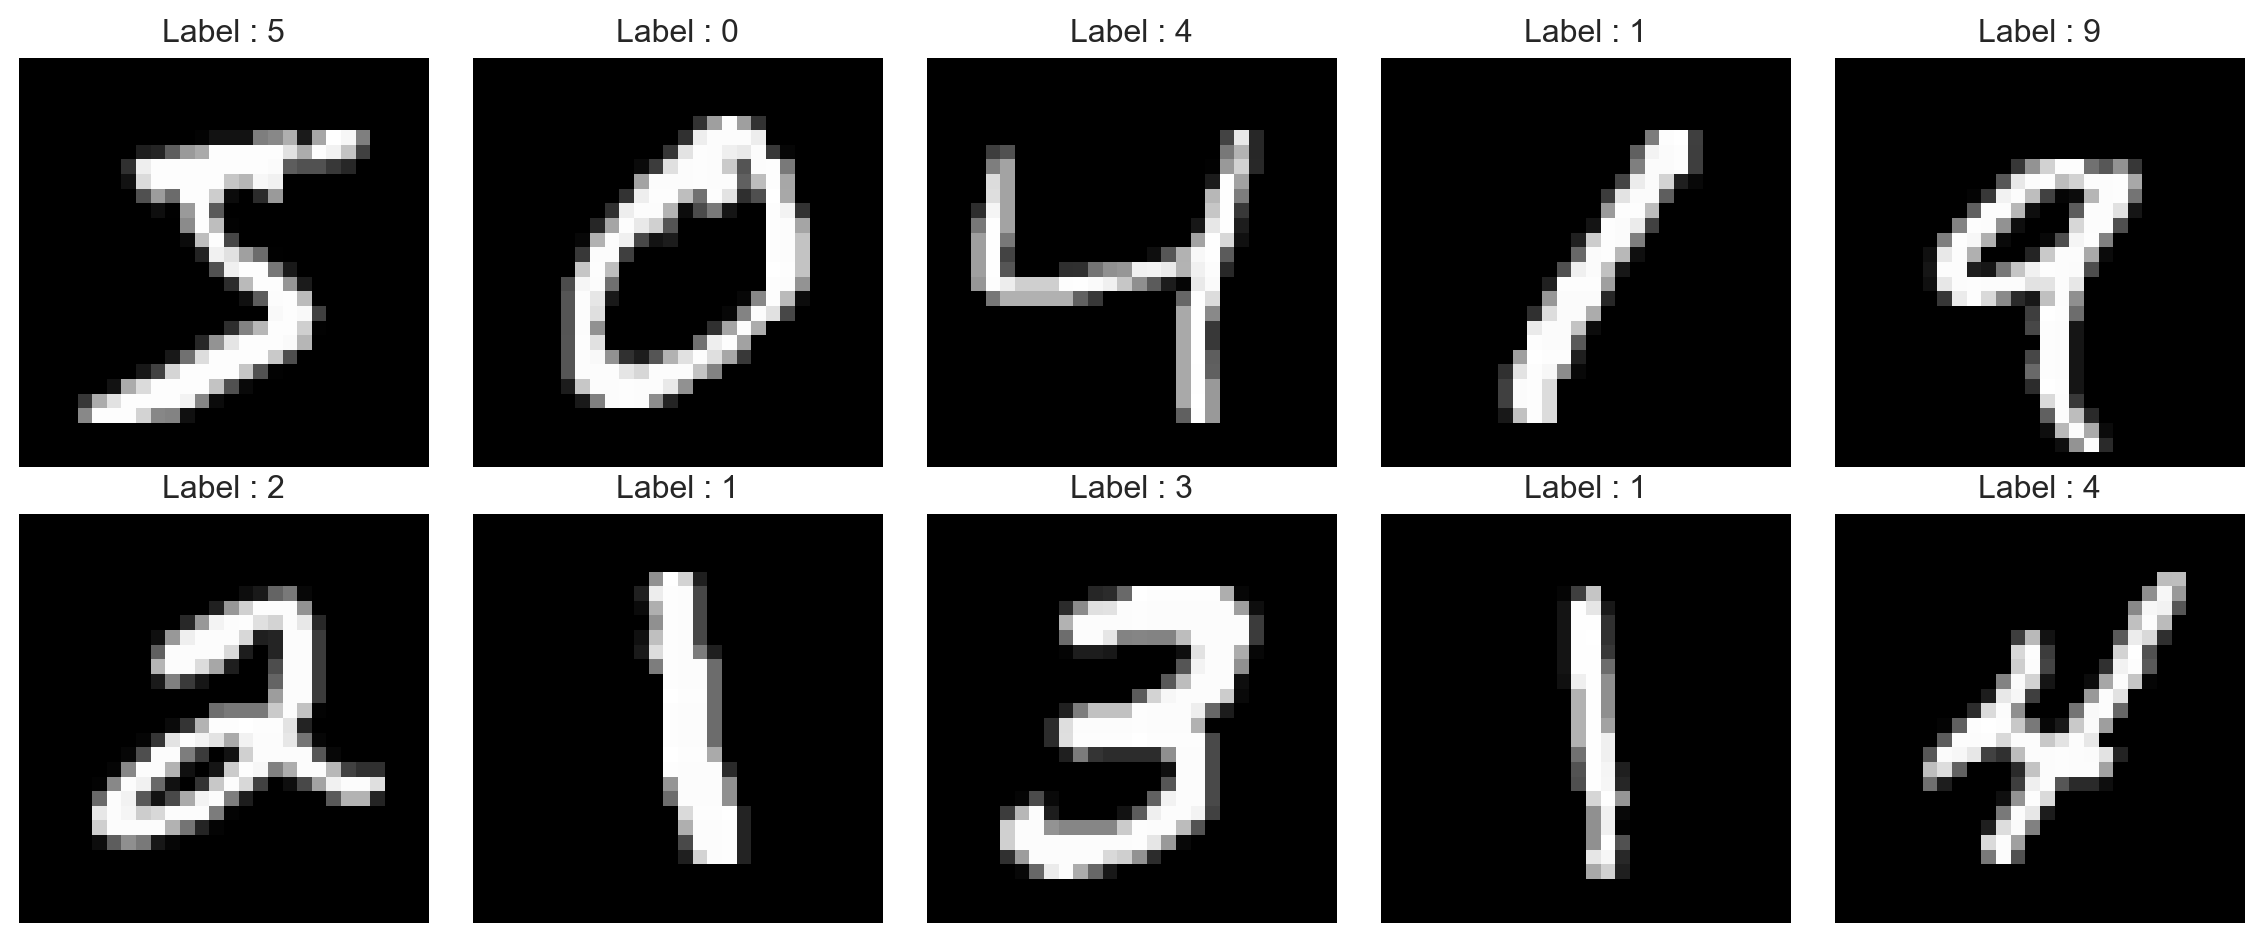

In [11]:
#| label: fig-mnist-samples
#| fig-cap: Exemples d'images MNIST

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for ax, i in zip(axes.flat, range(10)):
    img, label = train_set[i]
    # img est normalisé, on "dénormalise" pour l'affichage
    img_display = img.squeeze() * 0.3081 + 0.1307
    ax.imshow(img_display, cmap="gray")
    ax.set_title(f"Label : {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
# DataLoaders
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)

# Modèle + optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modele = LeNet(n_classes=10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(modele.parameters(), lr=1e-3)

print(f"Device : {device}")

Device : cpu


In [13]:
# Training loop (rapide : 3 epochs suffisent sur MNIST)
import time

n_epochs = 3
train_losses, test_accs = [], []

for epoch in range(n_epochs):
    t0 = time.time()
    
    # Entraînement
    modele.train()
    epoch_losses = []
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        logits = modele(Xb)
        loss = loss_fn(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    
    # Évaluation
    modele.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            preds = modele(Xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    acc = correct / total
    test_accs.append(acc)
    
    print(f"Époque {epoch+1}/{n_epochs} | Loss {train_losses[-1]:.4f} | Test acc {acc:.4f} | {time.time()-t0:.1f}s")

Époque 1/3 | Loss 0.2972 | Test acc 0.9714 | 13.6s


Époque 2/3 | Loss 0.0822 | Test acc 0.9834 | 14.0s


Époque 3/3 | Loss 0.0559 | Test acc 0.9864 | 14.0s


In [14]:
# MLP équivalent pour comparer
class MLPMnist(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, n_classes)
    def forward(self, x):
        x = x.view(x.size(0), -1)  # aplatir
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# Entraîner le MLP
mlp = MLPMnist().to(device)
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)

for epoch in range(3):
    mlp.train()
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = loss_fn(mlp(Xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()

# Évaluer
mlp.eval()
correct, total = 0, 0
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        correct += (mlp(Xb).argmax(dim=1) == yb).sum().item()
        total += yb.size(0)
acc_mlp = correct / total

# Comparaison
total_params_cnn = sum(p.numel() for p in modele.parameters())
total_params_mlp = sum(p.numel() for p in mlp.parameters())

print(f"\n=== Comparaison après 3 époques ===")
print(f"MLP  : accuracy {acc_mlp:.4f} | {total_params_mlp:,} paramètres")
print(f"CNN  : accuracy {test_accs[-1]:.4f} | {total_params_cnn:,} paramètres")


=== Comparaison après 3 époques ===
MLP  : accuracy 0.9710 | 109,386 paramètres
CNN  : accuracy 0.9864 | 61,706 paramètres


Shape des filtres : (6, 1, 5, 5)


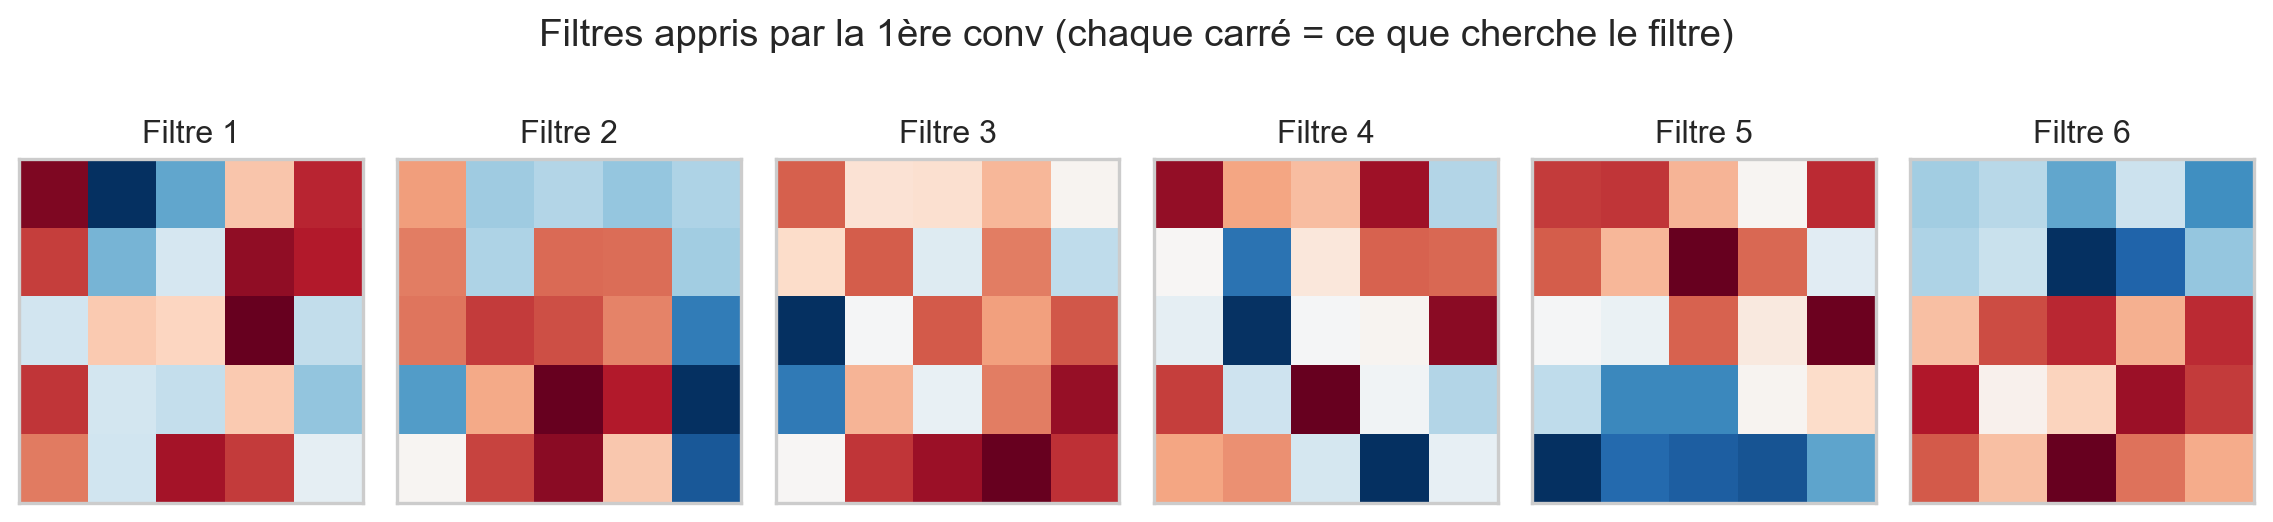

In [15]:
#| label: fig-filters-learned
#| fig-cap: Les 6 filtres appris par la première conv

# Récupérer les poids de la première conv
filtres = modele.conv1.weight.data.cpu().numpy()
print(f"Shape des filtres : {filtres.shape}")   # (6, 1, 5, 5)

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for ax, i in zip(axes, range(6)):
    ax.imshow(filtres[i, 0], cmap="RdBu_r")
    ax.set_title(f"Filtre {i+1}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("Filtres appris par la 1ère conv (chaque carré = ce que cherche le filtre)")
plt.tight_layout()
plt.show()

Shape : (6, 28, 28)


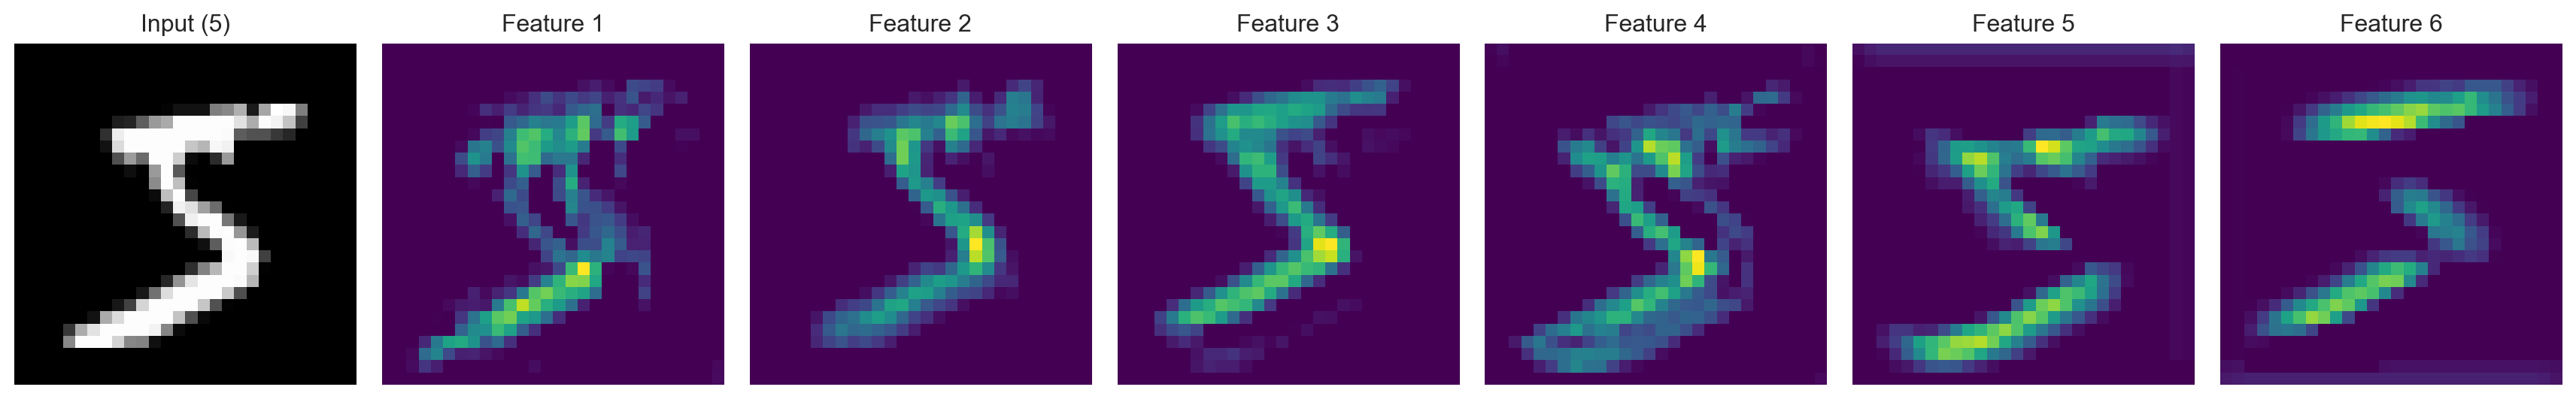

In [16]:
#| label: fig-feature-maps
#| fig-cap: Activations après la 1ère conv pour un 7

# Prendre une image test
img, label = train_set[0]  # un 5
img_batch = img.unsqueeze(0).to(device)

# Extraire la sortie après conv1
modele.eval()
with torch.no_grad():
    conv1_out = F.relu(modele.conv1(img_batch))

conv1_out_cpu = conv1_out.cpu().squeeze().numpy()
print(f"Shape : {conv1_out_cpu.shape}")   # (6, 28, 28)

fig, axes = plt.subplots(1, 7, figsize=(18, 3))

# Image originale
axes[0].imshow(img.squeeze().numpy() * 0.3081 + 0.1307, cmap="gray")
axes[0].set_title(f"Input ({label})")
axes[0].axis("off")

# 6 feature maps
for ax, i in zip(axes[1:], range(6)):
    ax.imshow(conv1_out_cpu[i], cmap="viridis")
    ax.set_title(f"Feature {i+1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
#| eval: false
# TODO: Exercice 1

In [18]:
# Charger Fashion-MNIST
transform_fmnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # stats Fashion-MNIST
])

f_train = torchvision.datasets.FashionMNIST(
    root=os.path.join(DATA_ROOT, "fmnist"), train=True, download=True, transform=transform_fmnist
)
f_test = torchvision.datasets.FashionMNIST(
    root=os.path.join(DATA_ROOT, "fmnist"), train=False, download=True, transform=transform_fmnist
)

print(f"Classes Fashion-MNIST : {f_train.classes}")

f_train_loader = DataLoader(f_train, batch_size=128, shuffle=True)
f_test_loader = DataLoader(f_test, batch_size=256)

# Même archi, nouveau modèle
fmodele = LeNet(n_classes=10).to(device)
f_optimizer = optim.Adam(fmodele.parameters(), lr=1e-3)

for epoch in range(3):
    fmodele.train()
    for Xb, yb in f_train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = loss_fn(fmodele(Xb), yb)
        f_optimizer.zero_grad(); loss.backward(); f_optimizer.step()

# Évaluer
fmodele.eval()
correct = 0; total = 0
with torch.no_grad():
    for Xb, yb in f_test_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        correct += (fmodele(Xb).argmax(dim=1) == yb).sum().item()
        total += yb.size(0)
acc_fmnist = correct / total

print(f"\nAccuracy Fashion-MNIST : {acc_fmnist:.4f}")
print(f"(vs MNIST : {test_accs[-1]:.4f})")

  0%|          | 0.00/26.4M [00:00<?, ?B/s]

  0%|          | 98.3k/26.4M [00:00<00:28, 919kB/s]

  2%|▏         | 590k/26.4M [00:00<00:08, 3.16MB/s]

  8%|▊         | 2.13M/26.4M [00:00<00:02, 8.57MB/s]

 15%|█▌        | 3.96M/26.4M [00:00<00:01, 12.3MB/s]

...

100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]

  0%|          | 0.00/5.15k [00:00<?, ?B/s]

100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Classes Fashion-MNIST : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



Accuracy Fashion-MNIST : 0.8709
(vs MNIST : 0.9864)


In [19]:
# Pipeline de transformations avec augmentation
transform_augment = transforms.Compose([
    transforms.RandomRotation(degrees=10),               # ±10°
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # translation ±10%
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Transform sans augmentation (pour le test)
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Train avec augmentation, test sans
train_aug = torchvision.datasets.MNIST(
    root=os.path.join(DATA_ROOT, "mnist"), train=True, download=True, transform=transform_augment
)

print(f"✅ Dataset avec augmentation créé")

✅ Dataset avec augmentation créé


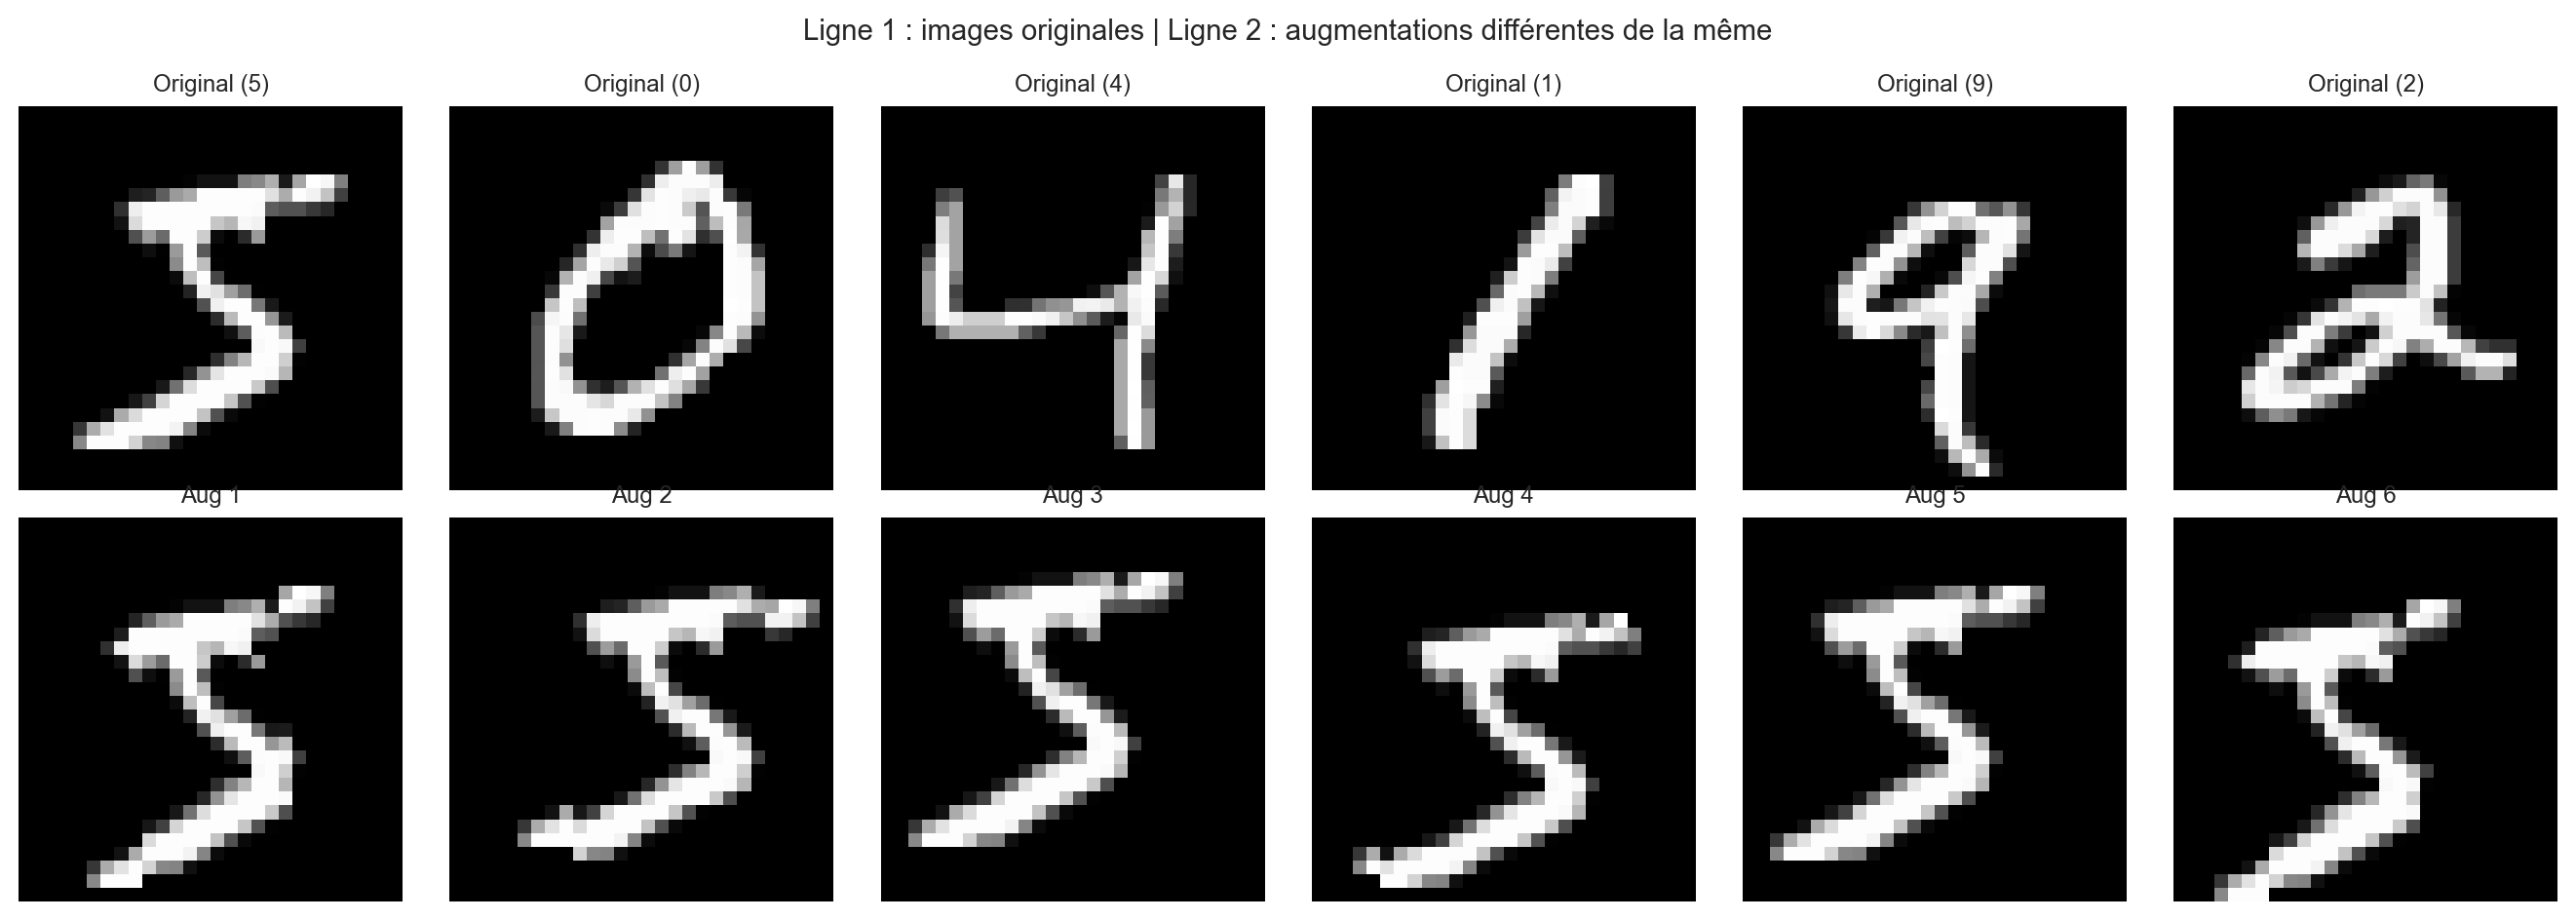

In [20]:
#| label: fig-augmentation
#| fig-cap: Une même image sous plusieurs transformations

# Récupérer la même image plusieurs fois → elle sera différente à chaque fois
fig, axes = plt.subplots(2, 6, figsize=(14, 5))

# Ligne 1 : original
for i in range(6):
    img, label = train_set[i]  # sans augmentation
    axes[0, i].imshow(img.squeeze() * 0.3081 + 0.1307, cmap="gray")
    axes[0, i].set_title(f"Original ({label})", fontsize=9)
    axes[0, i].axis("off")

# Ligne 2 : augmentations aléatoires du même exemple 0
img_0, lbl_0 = train_aug[0]
for i in range(6):
    # Récupérer une version augmentée (torchvision applique une aug différente chaque call)
    img, _ = train_aug[0]
    axes[1, i].imshow(img.squeeze() * 0.3081 + 0.1307, cmap="gray")
    axes[1, i].set_title(f"Aug {i+1}", fontsize=9)
    axes[1, i].axis("off")

plt.suptitle("Ligne 1 : images originales | Ligne 2 : augmentations différentes de la même", fontsize=11)
plt.tight_layout()
plt.show()

In [21]:
#| eval: false
# TODO: Exercice 2

In [22]:
from torch.utils.data import Subset

# Subset de 5000 images
indices = np.random.choice(len(train_set), 5000, replace=False).tolist()

# Sans augmentation
train_small = Subset(train_set, indices)
# Avec augmentation (on réutilise train_aug)
train_small_aug = Subset(train_aug, indices)

def entrainer_et_evaluer(dataset, epochs=5):
    torch.manual_seed(42)
    loader = DataLoader(dataset, batch_size=128, shuffle=True)
    m = LeNet(n_classes=10).to(device)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    
    for ep in range(epochs):
        m.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            loss = loss_fn(m(Xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    
    # Eval sur le test set complet (10k)
    m.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for Xb, yb in test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (m(Xb).argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
    return correct / total

acc_sans = entrainer_et_evaluer(train_small)
acc_avec = entrainer_et_evaluer(train_small_aug)

print(f"Sans augmentation : {acc_sans:.4f}")
print(f"Avec augmentation : {acc_avec:.4f}")
print(f"Gain : {(acc_avec - acc_sans) * 100:+.2f} points")

Sans augmentation : 0.9471
Avec augmentation : 0.9553
Gain : +0.82 points


In [23]:
# Transform avec augmentation pour vêtements
transform_fmnist_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),   # OK pour vêtements
    transforms.RandomRotation(degrees=5),
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

transform_fmnist_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

f_train_aug = torchvision.datasets.FashionMNIST(
    root=os.path.join(DATA_ROOT, "fmnist"), train=True, download=True, transform=transform_fmnist_aug
)
f_test_t = torchvision.datasets.FashionMNIST(
    root=os.path.join(DATA_ROOT, "fmnist"), train=False, download=True, transform=transform_fmnist_test
)

f_train_loader = DataLoader(f_train_aug, batch_size=128, shuffle=True)
f_test_loader = DataLoader(f_test_t, batch_size=256)

class DeepCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        # Bloc 1 : 28 -> 14
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        # Bloc 2 : 14 -> 7
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        # Bloc 3 : 7 -> 3
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Tête
        self.drop = nn.Dropout(0.3)
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, n_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 28 -> 14
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 14 -> 7
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 7 -> 3
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

torch.manual_seed(42)
modele_deep = DeepCNN(10).to(device)
optimizer = optim.Adam(modele_deep.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

n_params = sum(p.numel() for p in modele_deep.parameters())
print(f"Paramètres : {n_params:,}")

# Training
best_acc = 0.0
for epoch in range(5):
    t0 = time.time()
    modele_deep.train()
    losses = []
    for Xb, yb in f_train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = loss_fn(modele_deep(Xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        losses.append(loss.item())
    scheduler.step()
    
    # Eval
    modele_deep.eval()
    correct = 0; total = 0
    with torch.no_grad():
        for Xb, yb in f_test_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (modele_deep(Xb).argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
    acc = correct / total
    best_acc = max(best_acc, acc)
    print(f"Époque {epoch+1} | Loss {np.mean(losses):.4f} | Test acc {acc:.4f} | {time.time()-t0:.1f}s")

print(f"\n🎯 Meilleure accuracy Fashion-MNIST : {best_acc:.4f}")

Paramètres : 390,858


Époque 1 | Loss 0.4844 | Test acc 0.8768 | 36.3s


Époque 2 | Loss 0.3297 | Test acc 0.8904 | 36.2s


Époque 3 | Loss 0.2787 | Test acc 0.9059 | 37.0s


Époque 4 | Loss 0.2484 | Test acc 0.9076 | 37.6s


Époque 5 | Loss 0.2282 | Test acc 0.9192 | 39.9s

🎯 Meilleure accuracy Fashion-MNIST : 0.9192
